In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import json
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

FOLDER_MODEL = "model"
FOLDER_STATS = "model_stats"

In [2]:
data = pd.read_csv("data/processed.csv")

In [3]:
data.describe()

,Unnamed: 0,Attendance,Temp_Moy_C,Humidite_Moy_%,Pluie_Tot_mm,Neige_Tot_cm,Vent_Moy_kmh,Rafale_Max_kmh,avg_yellow_per_match,avg_red_per_match,...,Exterieur_Detailed_Saves_SurfaceReparation_away,Exterieur_Detailed_Saves_EnDehorsSurface_away,Exterieur_Detailed_Saves_Note_away,Exterieur_Detailed_Possession-loss_ControlesRatés_away,Exterieur_Detailed_Possession-loss_Dépossédé_away,Exterieur_Detailed_Possession-loss_Note_away,Exterieur_Detailed_Aerial_Total_away,Exterieur_Detailed_Aerial_Gagnés_away,Exterieur_Detailed_Aerial_Perdus_away,Exterieur_Detailed_Aerial_Note_away
count,8681.000000,8681.000000,8681.000000,8681.000000,8681.000000,8681.000000,8681.000000,8681.000000,8681.000000,8681.000000,...,8681.000000,8681.000000,8681.000000,8681.000000,8681.000000,8681.000000,8681.000000,8681.000000,8681.000000,8681.000000
mean,4340.000000,31695.396383,13.093780,71.921576,0.258956,0.002776,11.613178,27.044903,2.820068,0.096367,...,1.912775,1.076120,6.570629,15.279438,8.576454,6.570629,28.633717,14.126149,14.505495,6.570629
std,2506.133177,18695.998227,6.686599,17.260269,1.041943,0.047957,7.051152,14.151814,0.996643,0.089446,...,0.461241,0.321628,0.130149,1.587356,1.226253,0.130149,5.847858,2.938710,3.226249,0.130149
min,0.000000,250.000000,-10.400000,11.700000,0.000000,0.000000,0.200000,2.200000,0.000000,0.000000,...,0.600000,0.200000,6.260000,10.900000,5.300000,6.260000,12.000000,6.200000,5.800000,6.260000
25%,2170.000000,16779.000000,8.200000,60.300000,0.000000,0.000000,6.200000,15.800000,2.210000,0.030000,...,1.600000,0.900000,6.470000,14.300000,7.700000,6.470000,24.700000,12.200000,12.400000,6.470000
50%,4340.000000,27427.000000,12.700000,74.500000,0.000000,0.000000,10.100000,24.800000,2.560000,0.080000,...,1.900000,1.100000,6.560000,15.200000,8.500000,6.560000,27.900000,13.800000,14.100000,6.560000
75%,6510.000000,43782.000000,17.700000,86.000000,0.000000,0.000000,15.500000,35.300000,3.260000,0.150000,...,2.200000,1.300000,6.640000,16.300000,9.400000,6.640000,32.400000,15.900000,16.600000,6.640000
max,8680.000000,95745.000000,34.100000,100.000000,38.600000,1.600000,53.000000,106.600000,7.000000,1.000000,...,3.500000,2.200000,7.090000,21.000000,11.900000,7.090000,47.700000,24.000000,23.700000,7.090000


In [4]:
data = data.drop(columns=['Unnamed: 0'])

In [5]:
data.head()

,League,Season,Date,Time,Home,Score,Away,Attendance,Venue,Referee,...,Exterieur_Detailed_Saves_SurfaceReparation_away,Exterieur_Detailed_Saves_EnDehorsSurface_away,Exterieur_Detailed_Saves_Note_away,Exterieur_Detailed_Possession-loss_ControlesRatés_away,Exterieur_Detailed_Possession-loss_Dépossédé_away,Exterieur_Detailed_Possession-loss_Note_away,Exterieur_Detailed_Aerial_Total_away,Exterieur_Detailed_Aerial_Gagnés_away,Exterieur_Detailed_Aerial_Perdus_away,Exterieur_Detailed_Aerial_Note_away
0,La Liga,2025-2026,2025-08-15,19:00,Girona,1–3,Rayo Vallecano,12403.0,Estadi Municipal de Montilivi,Javier Alberola Rojas,...,1.6,0.8,6.44,17.5,8.5,6.44,21.6,8.9,12.7,6.44
1,La Liga,2025-2026,2025-08-15,21:30,Villarreal,2–0,Oviedo,18333.0,Estadio de la Cerámica,Alejandro Muñiz Ruiz,...,2.8,1.6,6.41,16.2,7.7,6.41,25.2,12.4,12.8,6.41
2,La Liga,2025-2026,2025-08-16,19:30,Mallorca,0–3,Barcelona,23318.0,Estadi Mallorca Son Moix,José Luis Munuera Montero,...,2.4,0.6,6.85,14.2,9.2,6.85,19.6,12.0,7.6,6.85
3,La Liga,2025-2026,2025-08-16,21:30,Alavés,2–1,Levante,12837.0,Estadio de Mendizorroza,Miguel Sesma Espinosa,...,2.9,0.8,6.48,15.8,7.6,6.48,27.2,13.2,14.1,6.48
4,La Liga,2025-2026,2025-08-16,21:30,Valencia,1–1,Real Sociedad,45333.0,Estadio de Mestalla,Jose Maria Sanchez Santos,...,1.8,1.0,6.55,15.1,7.4,6.55,26.9,13.8,13.1,6.55


In [6]:
# Calculer le nombre de valeurs manquantes par colonne
missing_stats = data.isnull().sum()

# Ne garder que les colonnes qui ont au moins une valeur manquante
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)

print("--- Attributs avec des données manquantes ---")
print(missing_stats)

--- Attributs avec des données manquantes ---
Series([], dtype: int64)


In [7]:
data.columns.tolist()

['League',
 'Season',
 'Date',
 'Time',
 'Home',
 'Score',
 'Away',
 'Attendance',
 'Venue',
 'Referee',
 'Temp_Moy_C',
 'Humidite_Moy_%',
 'Pluie_Tot_mm',
 'Neige_Tot_cm',
 'Vent_Moy_kmh',
 'Rafale_Max_kmh',
 'avg_yellow_per_match',
 'avg_red_per_match',
 'avg_goals_per_match',
 'avg_fouls_per_match',
 'Home_Manager',
 'Away_Manager',
 'preferred_formation_home',
 'profile_home',
 'team_style_home',
 'pressing_intensity_home',
 'defensive_line_home',
 'win_pct_home',
 'clean_sheet_pct_home',
 'fail_to_score_pct_home',
 'preferred_formation_away',
 'profile_away',
 'team_style_away',
 'pressing_intensity_away',
 'defensive_line_away',
 'win_pct_away',
 'clean_sheet_pct_away',
 'fail_to_score_pct_away',
 'Domicile_General_Buts_home',
 'Domicile_General_Tirs pm_home',
 'Domicile_General_Possession%_home',
 'Domicile_General_PassesRéussies%_home',
 'Domicile_General_AériensGagnés_home',
 'Domicile_General_Note_home',
 'Domicile_General_Cartons_J_home',
 'Domicile_General_Cartons_R_home',


In [8]:
# Extraction des buts et création de la variable Target (1, X, 2)
data[['Home_Goals', 'Away_Goals']] = data['Score'].str.split(r'[-–]', expand=True).astype(float)

conditions = [
    (data['Home_Goals'] > data['Away_Goals']),
    (data['Home_Goals'] == data['Away_Goals']),
    (data['Home_Goals'] < data['Away_Goals'])
]

# Ajout du paramètre default avec une chaîne de caractères
data['Target'] = np.select(conditions, ['1', 'X', '2'], default='Unknown')

/var/folders/nc/913x4t155x1gnc95b8q174xc0000gn/T/ipykernel_1947/2382808659.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[['Home_Goals', 'Away_Goals']] = data['Score'].str.split(r'[-–]', expand=True).astype(float)
/var/folders/nc/913x4t155x1gnc95b8q174xc0000gn/T/ipykernel_1947/2382808659.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Target'] = np.select(conditions, ['1', 'X', '2'], default='Unknown')


In [9]:
cols_to_drop = ['Score', 'Neige_Tot_cm', 'Referee', 'Time', 'Venue', 'Home_Manager', 'Away_Manager']

# Familles de variables trop granulaires ou redondantes
mots_cles_a_supprimer = [
    'DirectionsTirs', 'CotésUtilisés', 
    'Detailed_Assists', 'CausesCartons'
]

for mot in mots_cles_a_supprimer:
    cols_to_drop.extend([c for c in data.columns if mot in c])

data = data.drop(columns=cols_to_drop, errors='ignore')

In [10]:
data.shape

(8681, 262)

In [11]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True, format='mixed')
data = data.sort_values('Date').reset_index(drop=True)
# ---------------------------------------------------------
# 1. INITIALISATION DES DICTIONNAIRES DE SUIVI
# ---------------------------------------------------------
teams = pd.concat([data['Home'], data['Away']]).unique()

# Suivi de l'état de chaque équipe
team_stats = {team: {
    'last_date': pd.NaT,
    'pts_history': [],      # Historique des points
    'gd_history': [],       # Historique des différences de buts (Goal Difference)
    'xg_diff_history': [],  # Historique des différences d'xG
    'elo': 1500.0,          # Rating global
    'pi_home': 0.0,         # Force spécifique à domicile (Pi-Rating)
    'pi_away': 0.0          # Force spécifique à l'extérieur (Pi-Rating)
} for team in teams}

# Suivi des confrontations directes (Head-to-Head)
# Clé : tuple (Equipe_Domicile, Equipe_Exterieur) -> Valeur : liste des résultats (1 pour victoire domicile, 0 pour nul/défaite)
h2h_stats = {} 

# Constantes pour les algorithmes
K_ELO = 20
LAMBDA_PI = 0.1 # Vitesse d'apprentissage du Pi-Rating

# Création des nouvelles colonnes remplies de zéros/NaN
new_cols = [
    'Home_Rest_Days', 'Away_Rest_Days',
    'Home_Pts_L5', 'Away_Pts_L5',
    'Home_GD_L3', 'Away_GD_L3',
    'Home_xG_Diff_L3', 'Away_xG_Diff_L3',
    'H2H_Home_WinRate_L5',
    'Home_Elo', 'Away_Elo',
    'Home_Pi_Rating', 'Away_Pi_Rating'
]
for col in new_cols:
    data[col] = np.nan

# ---------------------------------------------------------
# 2. BOUCLE PRINCIPALE (SIMULATION CHRONOLOGIQUE)
# ---------------------------------------------------------
for idx, row in data.iterrows():
    home = row['Home']
    away = row['Away']
    date = row['Date']
    
    # ---------------------------------------------------------
    # A. RÉCUPÉRATION DES STATS PRÉ-MATCH (Pour le modèle)
    # ---------------------------------------------------------
    
    # Jours de repos
    if pd.notna(team_stats[home]['last_date']):
        data.at[idx, 'Home_Rest_Days'] = (date - team_stats[home]['last_date']).days
    else:
        data.at[idx, 'Home_Rest_Days'] = 14 # Valeur par défaut
        
    if pd.notna(team_stats[away]['last_date']):
        data.at[idx, 'Away_Rest_Days'] = (date - team_stats[away]['last_date']).days
    else:
        data.at[idx, 'Away_Rest_Days'] = 14
        
    # Dynamique (Forme) : Points sur les 5 derniers, GD sur les 3 derniers
    data.at[idx, 'Home_Pts_L5'] = sum(team_stats[home]['pts_history'][-5:]) if team_stats[home]['pts_history'] else 0
    data.at[idx, 'Away_Pts_L5'] = sum(team_stats[away]['pts_history'][-5:]) if team_stats[away]['pts_history'] else 0
    
    data.at[idx, 'Home_GD_L3'] = sum(team_stats[home]['gd_history'][-3:]) if team_stats[home]['gd_history'] else 0
    data.at[idx, 'Away_GD_L3'] = sum(team_stats[away]['gd_history'][-3:]) if team_stats[away]['gd_history'] else 0
    
    # Dynamique xG sur les 3 derniers matchs
    if team_stats[home]['xg_diff_history']:
        data.at[idx, 'Home_xG_Diff_L3'] = np.mean(team_stats[home]['xg_diff_history'][-3:])
    else:
        data.at[idx, 'Home_xG_Diff_L3'] = 0.0
        
    if team_stats[away]['xg_diff_history']:
        data.at[idx, 'Away_xG_Diff_L3'] = np.mean(team_stats[away]['xg_diff_history'][-3:])
    else:
        data.at[idx, 'Away_xG_Diff_L3'] = 0.0

    # Ratings Globaux
    data.at[idx, 'Home_Elo'] = team_stats[home]['elo']
    data.at[idx, 'Away_Elo'] = team_stats[away]['elo']
    data.at[idx, 'Home_Pi_Rating'] = team_stats[home]['pi_home']
    data.at[idx, 'Away_Pi_Rating'] = team_stats[away]['pi_away']
    
    # Head-to-Head (Taux de victoire domicile vs extérieur sur les 5 derniers affrontements)
    h2h_key = (home, away)
    if h2h_key in h2h_stats and len(h2h_stats[h2h_key]) > 0:
        data.at[idx, 'H2H_Home_WinRate_L5'] = np.mean(h2h_stats[h2h_key][-5:])
    else:
        data.at[idx, 'H2H_Home_WinRate_L5'] = 0.0 # Pas d'historique

    # ---------------------------------------------------------
    # B. MISES À JOUR POST-MATCH (Pour le futur)
    # ---------------------------------------------------------
    hg = row['Home_Goals']
    ag = row['Away_Goals']
    gd = hg - ag
    
    # Points
    if hg > ag:
        home_pts, away_pts = 3, 0
        h2h_result = 1
        s_home, s_away = 1, 0
    elif hg == ag:
        home_pts, away_pts = 1, 1
        h2h_result = 0
        s_home, s_away = 0.5, 0.5
    else:
        home_pts, away_pts = 0, 3
        h2h_result = 0
        s_home, s_away = 0, 1
        
    # Mise à jour de l'historique des listes
    team_stats[home]['pts_history'].append(home_pts)
    team_stats[away]['pts_history'].append(away_pts)
    
    team_stats[home]['gd_history'].append(gd)
    team_stats[away]['gd_history'].append(-gd)
    
    # Mise à jour des xG (REMPLACE PAR TES COLONNES xG RÉELLES DU MATCH)
    # Par exemple, si tu as 'Match_xG_Home' et 'Match_xG_Away' dans ton dataset
    if 'Match_xG_Home' in data.columns and 'Match_xG_Away' in data.columns:
        xg_diff = row['Match_xG_Home'] - row['Match_xG_Away']
        team_stats[home]['xg_diff_history'].append(xg_diff)
        team_stats[away]['xg_diff_history'].append(-xg_diff)
        
    # Mise à jour H2H
    if h2h_key not in h2h_stats:
        h2h_stats[h2h_key] = []
    h2h_stats[h2h_key].append(h2h_result)
    
    # Mise à jour Date
    team_stats[home]['last_date'] = date
    team_stats[away]['last_date'] = date
    
    # Mise à jour ELO
    exp_home = 1 / (1 + 10 ** ((team_stats[away]['elo'] - team_stats[home]['elo']) / 400))
    exp_away = 1 / (1 + 10 ** ((team_stats[home]['elo'] - team_stats[away]['elo']) / 400))
    team_stats[home]['elo'] += K_ELO * (s_home - exp_home)
    team_stats[away]['elo'] += K_ELO * (s_away - exp_away)
    
    # Mise à jour PI-RATING (Version simplifiée sur la différence de buts)
    # Le Pi-Rating traque indépendamment la force à domicile et à l'extérieur
    expected_gd = team_stats[home]['pi_home'] - team_stats[away]['pi_away']
    pi_error = gd - expected_gd
    team_stats[home]['pi_home'] += LAMBDA_PI * pi_error
    team_stats[away]['pi_away'] -= LAMBDA_PI * pi_error

# Nettoyage final des valeurs NaN (pour le tout premier match de l'historique)
data = data.fillna(0)

print("Création des variables dynamiques terminée !")

/var/folders/nc/913x4t155x1gnc95b8q174xc0000gn/T/ipykernel_1947/2853216159.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[col] = np.nan


Création des variables dynamiques terminée !


In [12]:
data.shape

(8681, 275)

In [13]:
data.columns.tolist()

['League',
 'Season',
 'Date',
 'Home',
 'Away',
 'Attendance',
 'Temp_Moy_C',
 'Humidite_Moy_%',
 'Pluie_Tot_mm',
 'Vent_Moy_kmh',
 'Rafale_Max_kmh',
 'avg_yellow_per_match',
 'avg_red_per_match',
 'avg_goals_per_match',
 'avg_fouls_per_match',
 'preferred_formation_home',
 'profile_home',
 'team_style_home',
 'pressing_intensity_home',
 'defensive_line_home',
 'win_pct_home',
 'clean_sheet_pct_home',
 'fail_to_score_pct_home',
 'preferred_formation_away',
 'profile_away',
 'team_style_away',
 'pressing_intensity_away',
 'defensive_line_away',
 'win_pct_away',
 'clean_sheet_pct_away',
 'fail_to_score_pct_away',
 'Domicile_General_Buts_home',
 'Domicile_General_Tirs pm_home',
 'Domicile_General_Possession%_home',
 'Domicile_General_PassesRéussies%_home',
 'Domicile_General_AériensGagnés_home',
 'Domicile_General_Note_home',
 'Domicile_General_Cartons_J_home',
 'Domicile_General_Cartons_R_home',
 'Domicile_Defense_Tirs pm_home',
 'Domicile_Defense_Tacles pm_home',
 'Domicile_Defense_Int

In [14]:
cols_to_drop = ['Exterieur_General_Buts_away', 'Exterieur_General_Cartons_J_away', "Exterieur_General_Cartons_R_away", "Exterieur_xG_Pour_xGDiff_away", 'Exterieur_xG_Contre_xGDiff_away', 'Domicile_General_Buts_home', 'Domicile_General_Cartons_J_home', "Domicile_General_Cartons_R_home", "Domicile_xG_Pour_xGDiff_home", 'Domicile_xG_Contre_xGDiff_home'] 

In [15]:
data = data.drop(columns = cols_to_drop)

In [16]:
attributs_bruts = [
    'Exterieur_xG_Pour_xG_away', 'Exterieur_xG_Pour_Buts*_away', 'Exterieur_xG_Pour_xGDiff_away',
    'Exterieur_xG_Pour_Tirs_away', 'Exterieur_xG_Contre_xG_away', 'Exterieur_xG_Contre_Buts*_away',
    'Exterieur_xG_Contre_xGDiff_away', 'Exterieur_xG_Contre_Tirs_away',
    'Exterieur_TypesButs_Pour_Dans Le Jeu_away', 'Exterieur_TypesButs_Pour_Contre-Attaque_away',
    'Exterieur_TypesButs_Pour_Coup de Pied Arrêté_away', 'Exterieur_TypesButs_Pour_Penalty_away',
    'Exterieur_TypesButs_Pour_Contre son Camp_away', 'Exterieur_TypesButs_Contre_Dans Le Jeu_away',
    'Exterieur_TypesButs_Contre_Contre-Attaque_away', 'Exterieur_TypesButs_Contre_Coup de Pied Arrêté_away',
    'Exterieur_TypesButs_Contre_Penalty_away', 'Exterieur_TypesButs_Contre_Contre son Camp_away'
]

# 2. Nettoyage pour récupérer uniquement la "racine" de l'attribut (en oubliant Exterieur et away)
attributs_racine = [col.replace('Exterieur_', '').replace('_away', '') for col in attributs_bruts]

# 3. Calcul du nombre de matchs joués par saison et par équipe (Domicile et Extérieur séparément)
# transform('count') compte le nombre d'apparitions et met le même chiffre sur toutes les lignes concernées
data['Nb_Matchs_Home_Saison'] = data.groupby(['Season', 'Home'])['Home'].transform('count')
data['Nb_Matchs_Away_Saison'] = data.groupby(['Season', 'Away'])['Away'].transform('count')

# 4. Boucle pour diviser chaque attribut par le nombre de matchs
for racine in attributs_racine:
    
    # Reconstitution des noms de colonnes exacts dans ton dataset
    col_home = f"Domicile_{racine}_home"
    col_away = f"Exterieur_{racine}_away"
    
    # Division pour l'équipe à Domicile (création d'une nouvelle colonne "_pm" pour "par match")
    if col_home in data.columns:
        data[f"{col_home}_pm"] = data[col_home] / data['Nb_Matchs_Home_Saison']
        data.drop(columns=col_home, inplace = True)
    # Division pour l'équipe à l'Extérieur
    if col_away in data.columns:
        data[f"{col_away}_pm"] = data[col_away] / data['Nb_Matchs_Away_Saison']
        data.drop(columns=col_away, inplace = True)
# Optionnel : Afficher le résultat pour vérifier
print(data[['Season', 'Home', 'Nb_Matchs_Home_Saison', f'Domicile_{attributs_racine[0]}_home_pm']].head())

      Season            Home  Nb_Matchs_Home_Saison  \
0  2021-2022            Köln                     17   
1  2021-2022        Cagliari                     19   
2  2021-2022   Athletic Club                     19   
3  2021-2022         Bologna                     19   
4  2021-2022  Rayo Vallecano                     19   

   Domicile_xG_Pour_xG_home_pm  
0                     1.575683  
1                     1.247368  
2                     1.670526  
3                     1.224211  
4                     1.435263  


/var/folders/nc/913x4t155x1gnc95b8q174xc0000gn/T/ipykernel_1947/332912109.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Nb_Matchs_Home_Saison'] = data.groupby(['Season', 'Home'])['Home'].transform('count')
/var/folders/nc/913x4t155x1gnc95b8q174xc0000gn/T/ipykernel_1947/332912109.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Nb_Matchs_Away_Saison'] = data.groupby(['Season', 'Away'])['Away'].transform('count')
/var/folders/nc/913x4t155x1gnc95b8q174xc0000gn/T/ipykernel_1947/332912109.py:29: PerformanceWarn

In [17]:
data.columns.tolist()

['League',
 'Season',
 'Date',
 'Home',
 'Away',
 'Attendance',
 'Temp_Moy_C',
 'Humidite_Moy_%',
 'Pluie_Tot_mm',
 'Vent_Moy_kmh',
 'Rafale_Max_kmh',
 'avg_yellow_per_match',
 'avg_red_per_match',
 'avg_goals_per_match',
 'avg_fouls_per_match',
 'preferred_formation_home',
 'profile_home',
 'team_style_home',
 'pressing_intensity_home',
 'defensive_line_home',
 'win_pct_home',
 'clean_sheet_pct_home',
 'fail_to_score_pct_home',
 'preferred_formation_away',
 'profile_away',
 'team_style_away',
 'pressing_intensity_away',
 'defensive_line_away',
 'win_pct_away',
 'clean_sheet_pct_away',
 'fail_to_score_pct_away',
 'Domicile_General_Tirs pm_home',
 'Domicile_General_Possession%_home',
 'Domicile_General_PassesRéussies%_home',
 'Domicile_General_AériensGagnés_home',
 'Domicile_General_Note_home',
 'Domicile_Defense_Tirs pm_home',
 'Domicile_Defense_Tacles pm_home',
 'Domicile_Defense_Interceptions pm_home',
 'Domicile_Defense_Fautes pm_home',
 'Domicile_Defense_Hors-jeux pm_home',
 'Domic

In [18]:
data.drop(columns = ['Nb_Matchs_Home_Saison','Nb_Matchs_Away_Saison', 'Home_Goals', 'Away_Goals'], inplace = True)

In [19]:
data.shape

(8681, 263)

In [20]:
data_train = data[data['Season'] != '2025-2026'].copy()
data_test = data[data['Season'] == '2025-2026'].copy()

cols_to_drop = ['Target', 'Date', 'Season']

features = [ col for col in data_train.columns if col not in cols_to_drop]

X_train = data_train[features]
y_train = data_train['Target']

X_test = data_test[features]
y_test = data_test['Target']

cat_features = X_train.select_dtypes(include=['object']).columns.tolist()


/var/folders/nc/913x4t155x1gnc95b8q174xc0000gn/T/ipykernel_1947/1695124461.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train.select_dtypes(include=['object']).columns.tolist()


In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# 1. Encodage de la Target ('1', 'X', '2' deviennent 0, 1, 2)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Affichage de la correspondance pour s'en souvenir
print("Correspondance des classes :", dict(zip(le.classes_, le.transform(le.classes_))))

Correspondance des classes : {'1': np.int64(0), '2': np.int64(1), 'X': np.int64(2)}


In [22]:
# ── Préparation commune à tous les modèles ──────────────────────────────────
# (à exécuter après la cellule qui définit X_train, X_test, y_train, y_test, cat_features, le)

import os, pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from time import time

os.makedirs("model_stats", exist_ok=True)

# Encodage de la target
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print("Classes :", dict(zip(le.classes_, le.transform(le.classes_))))

# Colonnes numériques uniquement (pour RF)
num_cols = [c for c in X_train.columns if c not in cat_features]

def plot_cm(cm, labels, title, path=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=[f"Pred {l}" for l in labels],
                yticklabels=[f"True {l}" for l in labels], ax=ax)
    ax.set_title(title); ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
    plt.tight_layout()
    if path: plt.savefig(path, dpi=120)
    plt.show()

def plot_importance(importances_df, top_n, title, path=None):
    df = importances_df.head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df["Feature"][::-1], df["Importance"][::-1])
    ax.set_title(title); ax.set_xlabel("Importance")
    plt.tight_layout()
    if path: plt.savefig(path, dpi=120)
    plt.show()

Classes : {'1': np.int64(0), '2': np.int64(1), 'X': np.int64(2)}


--- ENTRAÎNEMENT RANDOM FOREST ---
Accuracy Random Forest : 53.80%  (1.2s)
              precision    recall  f1-score   support

           0     0.6444    0.6425    0.6435       691
           1     0.5565    0.5729    0.5646       473
           2     0.3265    0.3167    0.3215       401

    accuracy                         0.5380      1565
   macro avg     0.5091    0.5107    0.5099      1565
weighted avg     0.5364    0.5380    0.5371      1565

Top 10 features RF :
                                  Feature  Importance
 Domicile_Detailed_Interception_Note_home    0.009529
      Exterieur_Detailed_Blocks_Note_away    0.008614
  Exterieur_Detailed_Key-passes_Note_away    0.008231
    Exterieur_Detailed_Dribbles_Note_away    0.008165
               Domicile_General_Note_home    0.008032
        Domicile_Detailed_Saves_Note_home    0.008026
             Domicile_xG_Contre_Note_home    0.007902
Exterieur_Detailed_Interception_Note_away    0.007901
       Domicile_Detailed_Blocks_Note_

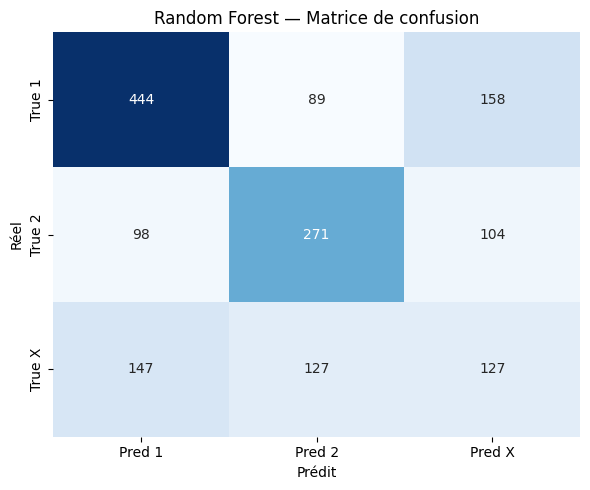

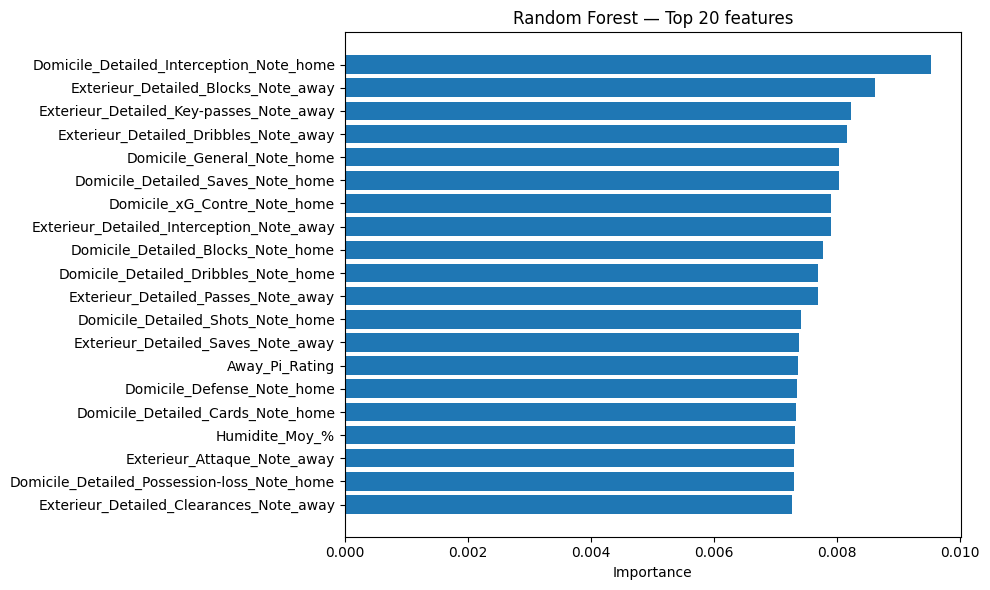

Modèle sauvegardé → model/rf.pkl


In [23]:
# ── Random Forest ────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

print("--- ENTRAÎNEMENT RANDOM FOREST ---")

Xtr_num = X_train[num_cols].fillna(0)
Xte_num = X_test[num_cols].fillna(0)

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

t0 = time()
rf_model.fit(Xtr_num, y_train_enc)
rf_time = time() - t0

rf_preds = rf_model.predict(Xte_num)
rf_acc   = accuracy_score(y_test_enc, rf_preds)
rf_report = classification_report(y_test_enc, rf_preds, digits=4)
rf_cm    = confusion_matrix(y_test_enc, rf_preds)

print(f"Accuracy Random Forest : {rf_acc:.2%}  ({rf_time:.1f}s)")
print(rf_report)

rf_importance = pd.DataFrame({
    'Feature': num_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 features RF :")
print(rf_importance.head(10).to_string(index=False))

os.makedirs(FOLDER_STATS + "/rf", exist_ok=True)
plot_cm(rf_cm, le.classes_, "Random Forest — Matrice de confusion",
        FOLDER_STATS + "/rf/confusion_matrix.png")
plot_importance(rf_importance, 20, "Random Forest — Top 20 features",
                FOLDER_STATS + "/rf/feature_importances.png")

with open(FOLDER_STATS + "/rf/report.txt", "w") as f:
    f.write(rf_report + f"\nTemps : {rf_time:.1f}s\n")

with open(FOLDER_MODEL + "/rf.pkl", "wb") as f:
    pickle.dump(rf_model, f)
print("Modèle sauvegardé → model/rf.pkl")

--- ENTRAÎNEMENT XGBOOST ---
[0]	validation_0-mlogloss:1.06400


/var/folders/nc/913x4t155x1gnc95b8q174xc0000gn/T/ipykernel_1947/2217600163.py:12: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  Xte_xgb[col] = pd.Categorical(Xte_xgb[col], categories=train_cats)
/var/folders/nc/913x4t155x1gnc95b8q174xc0000gn/T/ipykernel_1947/2217600163.py:12: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  Xte_xgb[col] = pd.Categorical(Xte_xgb[col], categories=train_cats)


[83]	validation_0-mlogloss:1.00991
Accuracy XGBoost : 52.52%  (1.2s)
              precision    recall  f1-score   support

           0     0.5638    0.7931    0.6590       691
           1     0.5111    0.4884    0.4995       473
           2     0.3050    0.1072    0.1587       401

    accuracy                         0.5252      1565
   macro avg     0.4599    0.4629    0.4391      1565
weighted avg     0.4815    0.5252    0.4826      1565

Top 10 features XGB :
                            Feature  Importance
 Domicile_Detailed_Goals_Total_home    0.064009
        Exterieur_General_Note_away    0.042056
         Domicile_General_Note_home    0.038412
         Domicile_xG_Pour_Note_home    0.026751
Exterieur_Detailed_Goals_Total_away    0.016031
        Exterieur_xG_Pour_Note_away    0.015406
                               Away    0.010354
                               Home    0.010211
   Domicile_xG_Contre_Buts*_home_pm    0.008723
    Exterieur_xG_Pour_Buts*_away_pm    0.007191


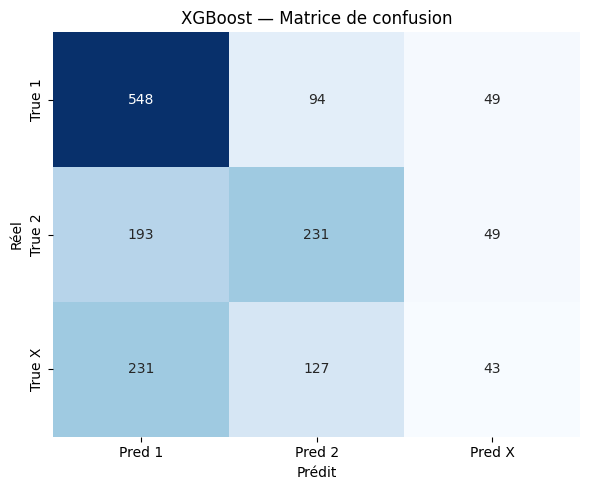

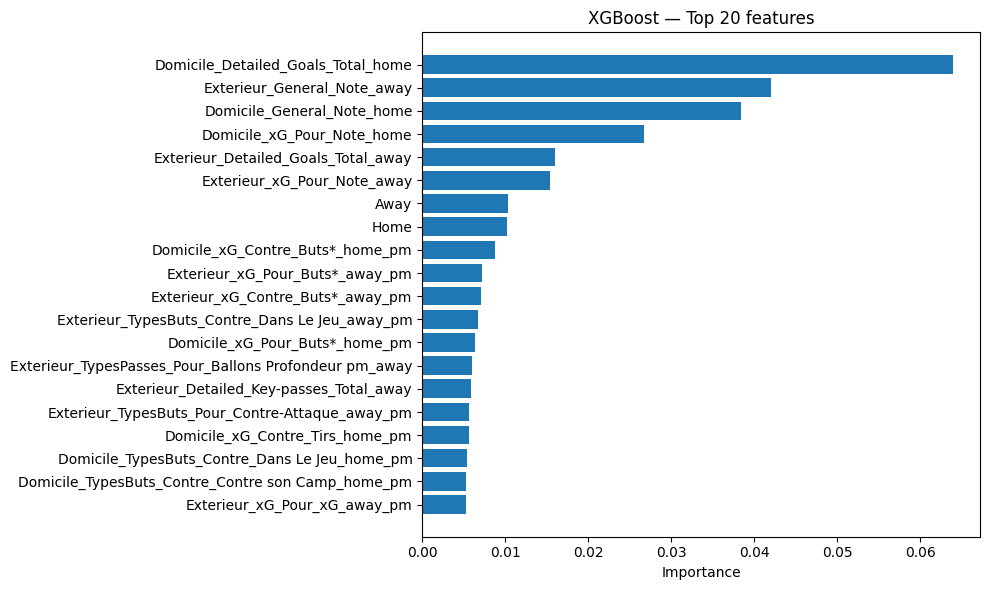

Modèle sauvegardé → model/xgb.pkl


In [24]:
# ── XGBoost ──────────────────────────────────────────────────────────────────
import xgboost as xgb

print("--- ENTRAÎNEMENT XGBOOST ---")

Xtr_xgb = X_train.copy()
Xte_xgb = X_test.copy()

for col in cat_features:
    Xtr_xgb[col] = Xtr_xgb[col].astype('category')
    train_cats   = Xtr_xgb[col].cat.categories
    Xte_xgb[col] = pd.Categorical(Xte_xgb[col], categories=train_cats)

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    tree_method='hist',
    enable_categorical=True,
    objective='multi:softprob',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0,
)

t0 = time()
xgb_model.fit(Xtr_xgb, y_train_enc,
              eval_set=[(Xte_xgb, y_test_enc)],
              verbose=100)
xgb_time = time() - t0

xgb_preds  = xgb_model.predict(Xte_xgb)
xgb_acc    = accuracy_score(y_test_enc, xgb_preds)
xgb_report = classification_report(y_test_enc, xgb_preds, digits=4)
xgb_cm     = confusion_matrix(y_test_enc, xgb_preds)

print(f"Accuracy XGBoost : {xgb_acc:.2%}  ({xgb_time:.1f}s)")
print(xgb_report)

xgb_importance = pd.DataFrame({
    'Feature': Xtr_xgb.columns.tolist(),
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 features XGB :")
print(xgb_importance.head(10).to_string(index=False))

os.makedirs(FOLDER_STATS + "/xgb", exist_ok=True)
plot_cm(xgb_cm, le.classes_, "XGBoost — Matrice de confusion",
        FOLDER_STATS + "/xgb/confusion_matrix.png")
plot_importance(xgb_importance, 20, "XGBoost — Top 20 features",
                FOLDER_STATS + "/xgb/feature_importances.png")

with open(FOLDER_STATS + "/xgb/report.txt", "w") as f:
    f.write(xgb_report + f"\nTemps : {xgb_time:.1f}s\n")

with open(FOLDER_MODEL + "/xgb.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
print("Modèle sauvegardé → model/xgb.pkl")

--- ENTRAÎNEMENT CATBOOST ---
0:	learn: 0.4962017	test: 0.4769108	best: 0.4769108 (0)	total: 72.4ms	remaining: 1m 12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5148117624
bestIteration = 31

Shrink model to first 32 iterations.
Accuracy CatBoost : 53.10%  (1.5s)
              precision    recall  f1-score   support

           0     0.6779    0.5818    0.6262       691
           1     0.5465    0.5835    0.5644       473
           2     0.3276    0.3815    0.3525       401

    accuracy                         0.5310      1565
   macro avg     0.5174    0.5156    0.5144      1565
weighted avg     0.5484    0.5310    0.5374      1565

Top 10 features CatBoost :
                                 Feature  Importance
     Exterieur_Detailed_Passes_Note_away    4.438343
            Domicile_xG_Contre_Note_home    4.352841
    Exterieur_Detailed_Tackles_Note_away    4.303638
              Domicile_Attaque_Note_home    4.046880
              Domicile_xG_Pour_Note_ho

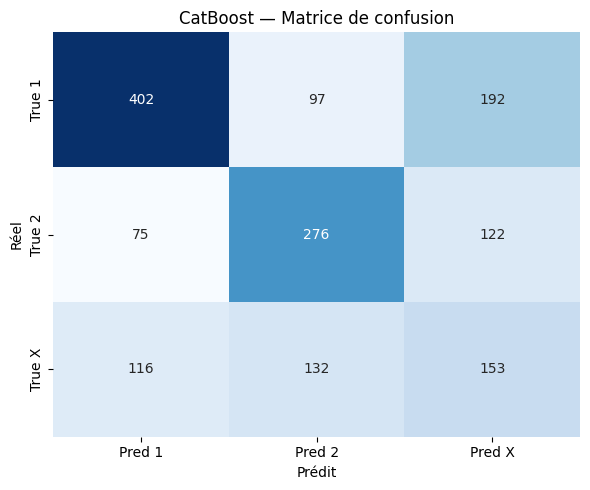

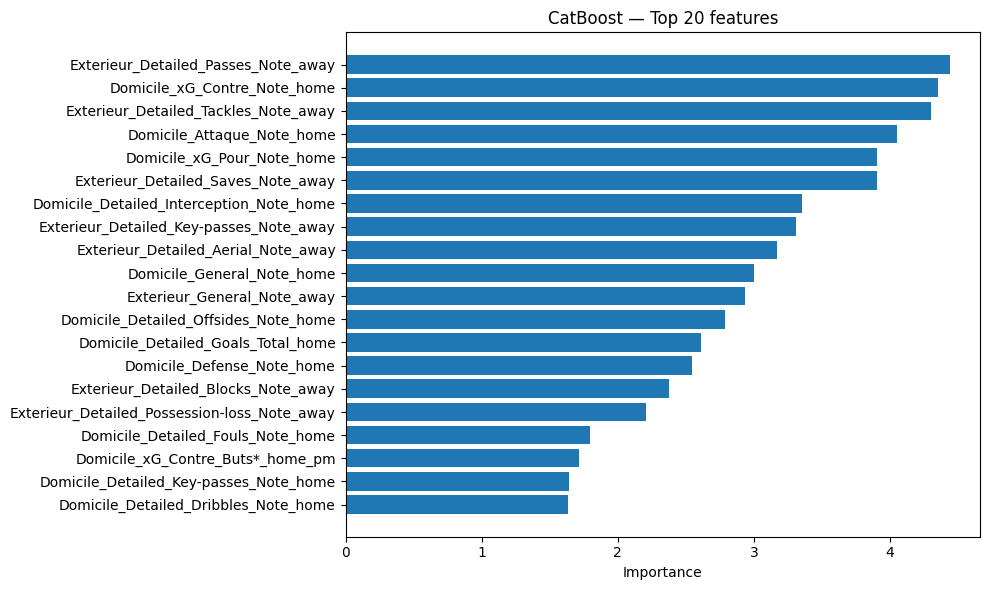

Modèle sauvegardé → model/catboost_simple.cbm


In [25]:
# ── CatBoost ─────────────────────────────────────────────────────────────────
from catboost import CatBoostClassifier, Pool

print("--- ENTRAÎNEMENT CATBOOST ---")

# Remplir les NaN dans les catégorielles
Xtr_cat = X_train.copy()
Xte_cat = X_test.copy()
Xtr_cat[cat_features] = Xtr_cat[cat_features].fillna('Missing')
Xte_cat[cat_features] = Xte_cat[cat_features].fillna('Missing')

train_pool = Pool(data=Xtr_cat, label=y_train_enc, cat_features=cat_features)
test_pool  = Pool(data=Xte_cat, label=y_test_enc,  cat_features=cat_features)

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='Accuracy',
    auto_class_weights='Balanced',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100,
)

t0 = time()
cat_model.fit(train_pool, eval_set=test_pool)
cat_time = time() - t0

cat_preds  = cat_model.predict(Xte_cat).flatten()
cat_acc    = accuracy_score(y_test_enc, cat_preds)
cat_report = classification_report(y_test_enc, cat_preds, digits=4)
cat_cm     = confusion_matrix(y_test_enc, cat_preds)

print(f"Accuracy CatBoost : {cat_acc:.2%}  ({cat_time:.1f}s)")
print(cat_report)

cat_importance = pd.DataFrame({
    'Feature': Xtr_cat.columns.tolist(),
    'Importance': cat_model.get_feature_importance()
}).sort_values('Importance', ascending=False)

print("Top 10 features CatBoost :")
print(cat_importance.head(10).to_string(index=False))

os.makedirs(FOLDER_STATS + "/catboost", exist_ok=True)
plot_cm(cat_cm, le.classes_, "CatBoost — Matrice de confusion",
        FOLDER_STATS + "/catboost/confusion_matrix.png")
plot_importance(cat_importance, 20, "CatBoost — Top 20 features",
                FOLDER_STATS + "/catboost/feature_importances.png")

with open(FOLDER_STATS + "/catboost/report.txt", "w") as f:
    f.write(cat_report + f"\nTemps : {cat_time:.1f}s\n")

cat_model.save_model(FOLDER_MODEL + "/catboost.cbm")
print("Modèle sauvegardé → model/catboost_simple.cbm")

In [ ]:
# ── Quantum Neural Network ───────────────────────────────────────────────────
import random, numpy as np, torch, torch.nn as nn
import pennylane as qml
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
N_QUBITS  = 7
QNN_REPS  = 3
N_CLASSES = len(le.classes_)   # 3  (1, X, 2)
dev = qml.device('lightning.qubit', wires=N_QUBITS)

# ── Préparation des données (sans PCA) ───────────────────────────────────────
Xtr_raw = X_train[num_cols].fillna(0).values
Xte_raw = X_test[num_cols].fillna(0).values
N_FEATURES = Xtr_raw.shape[1]

scaler_q = StandardScaler()
Xtr_s = scaler_q.fit_transform(Xtr_raw)
Xte_s = scaler_q.transform(Xte_raw)

# --- AJOUT POUR L'INFÉRENCE ---
with open(FOLDER_MODEL + "/qnn_scaler.pkl", "wb") as f:
    pickle.dump(scaler_q, f)
with open(FOLDER_MODEL + "/qnn_le.pkl", "wb") as f:
    pickle.dump(le, f)
with open(FOLDER_MODEL + "/qnn_cols.pkl", "wb") as f:
    pickle.dump(num_cols, f)
print("Scaler, LabelEncoder et features sauvegardés pour l'inférence.")

def _t(a):  return torch.from_numpy(a.copy()).float()
def _tl(a): return torch.from_numpy(a.copy().astype(np.int64))

# Split val / test sur X_test (50 / 50)
val_size  = int(0.5 * len(Xte_s))
Xval_s,  Xte_s2   = Xte_s[:val_size],     Xte_s[val_size:]
yval_enc, yte_enc  = y_test_enc[:val_size], y_test_enc[val_size:]

train_loader_q = DataLoader(
    TensorDataset(_t(Xtr_s), _tl(y_train_enc)), batch_size=32, shuffle=True)
val_loader_q = DataLoader(
    TensorDataset(_t(Xval_s), _tl(yval_enc)), batch_size=32, shuffle=False)
Xq_te_t = _t(Xte_s2)
yq_te_t = _tl(yte_enc)

# ── Circuit quantique ─────────────────────────────────────────────────────────
@qml.qnode(dev, interface='torch', diff_method='best')
def qnode(x, theta):
    qml.templates.AngleEmbedding(x, wires=range(N_QUBITS))
    qml.templates.StronglyEntanglingLayers(theta, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_CLASSES)]

class QNodeLayer(nn.Module):
    """Couche quantique : (batch, N_QUBITS) → (batch, N_CLASSES)"""
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.randn(QNN_REPS, N_QUBITS, 3) * 0.1)

    def forward(self, x):
        x = x.float()
        if x.ndim == 1: x = x.unsqueeze(0)
        outs = []
        for i in range(x.shape[0]):
            ev = qnode(x[i], self.theta)
            outs.append(torch.stack(ev))
        return torch.stack(outs)               # (batch, N_CLASSES)

class HybridQNN(nn.Module):
    """
    Pipeline DNN classique → quantique → DNN classique

    pre_net  : N_FEATURES → 128 → 64 → 32 → N_QUBITS   (3 réductions + projection finale)
    q_layer  : circuit variationnel PennyLane
    post_net : N_CLASSES  → N_CLASSES                    (ajustement des logits)
    """
    def __init__(self, n_features):
        super().__init__()
        self.pre_net = nn.Sequential(
            # Couche 1 : N_FEATURES → 256
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            # Couche 2 : 256 → 128
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            # Couche 3 : 128 → 64
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
            # Couche 4 : 64 → 32
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Projection finale vers N_QUBITS angles
            nn.Linear(32, N_QUBITS),
            nn.Tanh(),             # borne dans (-1,1) → angles stables pour AngleEmbedding
        )
        self.q_layer  = QNodeLayer()
        self.post_net = nn.Sequential(
            nn.Linear(N_CLASSES, N_CLASSES),
        )

    def forward(self, x):
        x = self.pre_net(x)        # (batch, N_QUBITS)
        x = self.q_layer(x)        # (batch, N_CLASSES)
        x = self.post_net(x)       # (batch, N_CLASSES)
        return x

qnn_model = HybridQNN(n_features=N_FEATURES).float()
print(qnn_model)
print(f"\nNombre de paramètres : {sum(p.numel() for p in qnn_model.parameters()):,}")

# ── Entraînement avec ReduceLROnPlateau + Early Stopping ─────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(qnn_model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',         # minimise val_loss
    factor=0.5,         # divise le LR par 2
    patience=2,         # attend 2 epochs sans amélioration
    min_lr=1e-6,
)

EARLY_STOPPING_PATIENCE = 8
best_val, best_state, no_improve = float('inf'), None, 0
qnn_history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'lr']}

for epoch in range(1, 101):
    # ── Train ────────────────────────────────────────────────────────────────
    qnn_model.train()
    tr_loss, tr_ok = 0.0, 0
    for xb, yb in train_loader_q:
        optimizer.zero_grad()
        logits = qnn_model(xb)
        l = criterion(logits, yb)
        l.backward()
        optimizer.step()
        tr_loss += l.item() * xb.size(0)
        tr_ok   += (logits.argmax(1) == yb).sum().item()
    tr_loss /= len(train_loader_q.dataset)
    tr_acc   = tr_ok / len(train_loader_q.dataset)

    # ── Validation ───────────────────────────────────────────────────────────
    qnn_model.eval()
    va_loss, va_ok = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader_q:
            logits = qnn_model(xb)
            va_loss += criterion(logits, yb).item() * xb.size(0)
            va_ok   += (logits.argmax(1) == yb).sum().item()
    va_loss /= len(val_loader_q.dataset)
    va_acc   = va_ok / len(val_loader_q.dataset)

    current_lr = optimizer.param_groups[0]['lr']
    for k, v in zip(qnn_history, [tr_loss, va_loss, tr_acc, va_acc, current_lr]):
        qnn_history[k].append(v)

    print(f"Epoch {epoch:03d}/100 — loss: {tr_loss:.4f} | val_loss: {va_loss:.4f} | "
          f"acc: {tr_acc:.4f} | val_acc: {va_acc:.4f} | lr: {current_lr:.2e}")

# ── ReduceLROnPlateau ────────────────────────────────────────────────────
    scheduler.step(va_loss)

    # ── Early Stopping ───────────────────────────────────────────────────────
    if va_loss < best_val:
        best_val   = va_loss
        best_state = {k: v.clone() for k, v in qnn_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping à l'epoch {epoch} "
                  f"(pas d'amélioration depuis {EARLY_STOPPING_PATIENCE} epochs)")
            break

    # ── Log APRÈS scheduler.step() pour voir le LR effectif ─────────────────
    current_lr = optimizer.param_groups[0]['lr']
    for k, v in zip(qnn_history, [tr_loss, va_loss, tr_acc, va_acc, current_lr]):
        qnn_history[k].append(v)

    prev_lr = qnn_history['lr'][-2] if len(qnn_history['lr']) >= 2 else current_lr
    lr_tag  = " ← LR réduit" if current_lr < prev_lr else ""
    print(f"Epoch {epoch:03d}/100 — loss: {tr_loss:.4f} | val_loss: {va_loss:.4f} | "
          f"acc: {tr_acc:.4f} | val_acc: {va_acc:.4f} | lr: {current_lr:.2e}{lr_tag}")

# ── Évaluation ───────────────────────────────────────────────────────────────
qnn_model.eval()
with torch.no_grad():
    qnn_logits = qnn_model(Xq_te_t)
qnn_preds  = qnn_logits.argmax(1).numpy()
qnn_acc    = accuracy_score(yq_te_t.numpy(), qnn_preds)
qnn_report = classification_report(yq_te_t.numpy(), qnn_preds, digits=4)
qnn_cm     = confusion_matrix(yq_te_t.numpy(), qnn_preds)

print(f"Accuracy QNN : {qnn_acc:.2%}")
print(qnn_report)

# ── Visualisations ───────────────────────────────────────────────────────────
os.makedirs(FOLDER_STATS + "/quantum", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(qnn_history['train_loss'], label='Train')
axes[0].plot(qnn_history['val_loss'],   label='Val')
axes[0].set_title('QNN — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(qnn_history['train_acc'], label='Train')
axes[1].plot(qnn_history['val_acc'],   label='Val')
axes[1].set_title('QNN — Accuracy'); axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(True)

axes[2].plot(qnn_history['lr'])
axes[2].set_title('QNN — Learning Rate'); axes[2].set_yscale('log')
axes[2].grid(True)

plt.tight_layout()
plt.savefig(FOLDER_STATS + "/quantum/curves.png", dpi=120)
plt.show()

plot_cm(qnn_cm, le.classes_, "QNN — Matrice de confusion",
        FOLDER_STATS + "/quantum/confusion_matrix.png")

with open(FOLDER_STATS + "/quantum/report.txt", "w") as f:
    f.write(qnn_report + f"\nN_qubits : {N_QUBITS} | Seed : {SEED}\n")

os.makedirs(FOLDER_MODEL, exist_ok=True)
torch.save(qnn_model.state_dict(), FOLDER_MODEL + "/quantum.pth")
print("Modèle QNN sauvegardé → model/quantum_simple.pth")



Scaler, LabelEncoder et features sauvegardés pour l'inférence.



       COMPARAISON DES MODÈLES
  QNN (binaire)      0.5543  ██████████████████████
  Random Forest      0.5406  █████████████████████
  CatBoost           0.5310  █████████████████████
  XGBoost            0.5208  ████████████████████


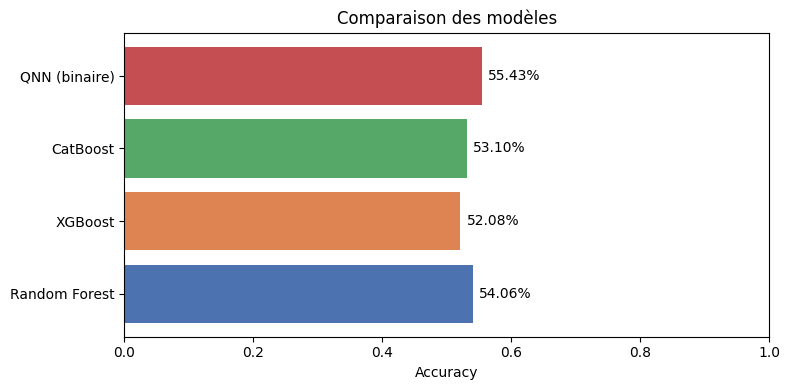

In [ ]:
# ── Comparaison des modèles ───────────────────────────────────────────────────
comparison = {
    'Random Forest': rf_acc,
    'XGBoost':       xgb_acc,
    'CatBoost':      cat_acc,
    'QNN (binaire)': qnn_acc,
}

print("\n" + "="*45)
print("       COMPARAISON DES MODÈLES")
print("="*45)
for name, acc in sorted(comparison.items(), key=lambda x: -x[1]):
    bar = "█" * int(acc * 40)
    print(f"  {name:<18} {acc:.4f}  {bar}")
print("="*45)

# Graphe récapitulatif
fig, ax = plt.subplots(figsize=(8, 4))
names = list(comparison.keys())
accs  = [comparison[n] for n in names]
bars  = ax.barh(names, accs, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy")
ax.set_title("Comparaison des modèles")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{acc:.2%}", va='center')
plt.tight_layout()
plt.savefig("model_stats/comparison.png", dpi=120)
plt.show()